<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

Cloning into 'IntroToAI_A2'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 14 (delta 1), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 24.43 KiB | 24.43 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/IntroToAI_A2


imported libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

loading in data

In [4]:
df = pd.read_csv('a2_Hannah_Taylor_40443054/40443054_features.csv')

Task 1.1

Confusion Matrix:
 [[10  2]
 [ 0 12]]
Accuracy: 0.9167
TPR (Recall): 1.0000
FPR: 0.1667
Precision: 0.8571
F1-Score: 0.9231
    Actual_Class  Living_Probability  Prediction_at_0.5
60         lemon            0.983226                  1
16        cherry            0.960843                  1
50      golfclub            0.149527                  0
95          tree            0.796362                  1
39      envelope            0.047350                  0
110         wine            0.000486                  0
75        pencil            0.840911                  1
91          tree            0.865462                  1
21        cherry            0.985219                  1
59         lemon            0.998618                  1


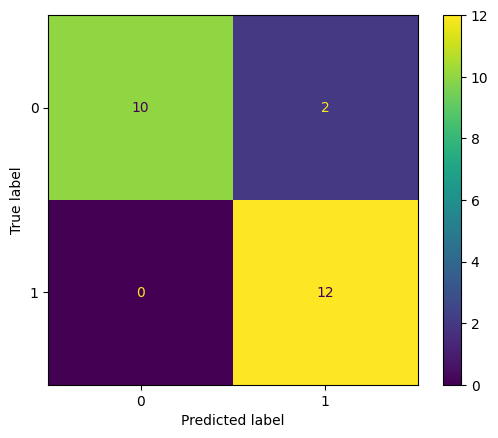

In [17]:
#living = 1, non-living = 0
living_classes = ['cherry', 'banana', 'lemon', 'tree']
df['is_living'] = df['label'].isin(living_classes).astype(int)

#stratify the test set
train_df, test_df = train_test_split(
    df,
    test_size=24,
    stratify=df['label'],
    random_state=42
)

my_features = ['rows_with_1', 'cols_with_2', 'eyes', 'hollowness']
X_train = train_df[my_features]
y_train = train_df['is_living']
X_test = test_df[my_features]
y_test = test_df['is_living']

# 5. Fit Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

#decision threshold is automatically 0.5 (https://www.geeksforgeeks.org/data-science/what-is-the-default-threshold-in-sklearn-logistic-regression/)
y_pred = model.predict(X_test)

#probability
y_probs = model.predict_proba(X_test)

#second column is living
living_probabilities = y_probs[:, 1]

#able to see the actual items and the repsective probabilities
results_df = pd.DataFrame({
    'Actual_Class': test_df['label'],
    'Living_Probability': living_probabilities,
    'Prediction_at_0.5': y_pred
})

cm = confusion_matrix(y_test, y_pred)
#positions got from slides
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

# Calculate specific metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "TPR (Recall)": recall_score(y_test, y_pred),
    "FPR": fp / (fp + tn),
    "Precision": precision_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred)
}

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print(results_df.head(10))

#from: (https://www.w3schools.com/python/python_ml_confusion_matrix.asp#:~:text=It%20is%20a%20table%20that,see%20which%20predictions%20are%20wrong.)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.savefig('confusionMatrix.png')
plt.show()